# Customer Behavior Analysis and Churn Prediction
## Prepared by: Hamadullah Rajper

### 1. Project Overview

This project aims to analyze customer transactional data to understand behavioral patterns and predict churn. The objective is to move beyond descriptive analytics and deliver actionable insights that support customer retention strategies.

The key goals are:

Segment customers based on value using RFM analysis
Build a predictive model to identify churn risk
Align analytical outputs with business decision-making
Recommend targeted retention strategies

### 2. Dataset Description

The dataset used is the Telco Customer Churn dataset, which includes:

Customer demographic information
Service subscription details
Account and billing data
Customer tenure
Churn status (target variable)

### 3. Loading Dataset

In [3]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 4. Data Cleaning and Preprocessing
 4.1 Handling Missing Values

The TotalCharges column contains non-numeric values that must be corrected.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

4.2 Removing Irrelevant Columns

In [5]:
df.drop('customerID', axis=1, inplace=True)

4.3 Encoding Categorical Variables

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

### 5. Exploratory Data Analysis
5.1 Churn Distribution

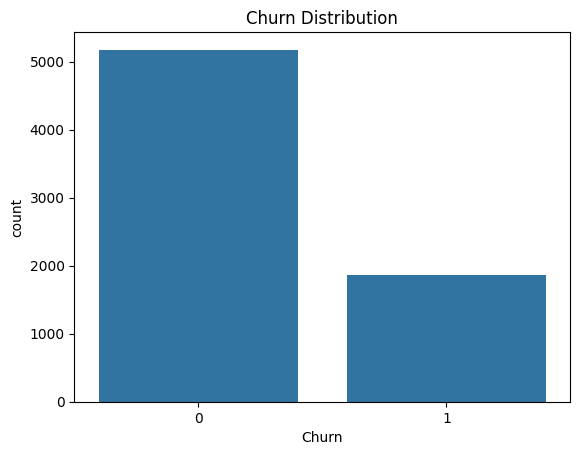

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

5.2 Observations
The dataset shows class imbalance between churned and non-churned customers
Customer tenure and billing-related features appear influential
Further analysis is required to quantify feature impact

### 6. Customer Segmentation using RFM

RFM analysis is used to classify customers based on:

Recency: Proxy using tenure
Frequency: Monthly billing behavior
Monetary: Total customer spending

6.1 Constructing RFM Table

In [8]:
rfm = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
rfm.columns = ['Recency', 'Frequency', 'Monetary']

6.2 Feature Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

rfm = pd.DataFrame(rfm_scaled, columns=rfm.columns)

6.3 RFM Scoring

In [10]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

6.4 Customer Segmentation

In [11]:
def segment(score):
    if score >= 12:
        return "High Value"
    elif score >= 8:
        return "Mid Value"
    else:
        return "Low Value"

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

### 7. Churn Prediction Model
7.1 Feature and Target Definition

In [13]:
X = df.drop('Churn', axis=1)
y = df['Churn']

7.2 Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

7.3 Model Training

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

7.4 Predictions

In [16]:
y_pred = model.predict(X_test)

### 8. Model Evaluation

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409

ROC-AUC Score: 0.6920060140569524


### 9. Feature Importance Analysis

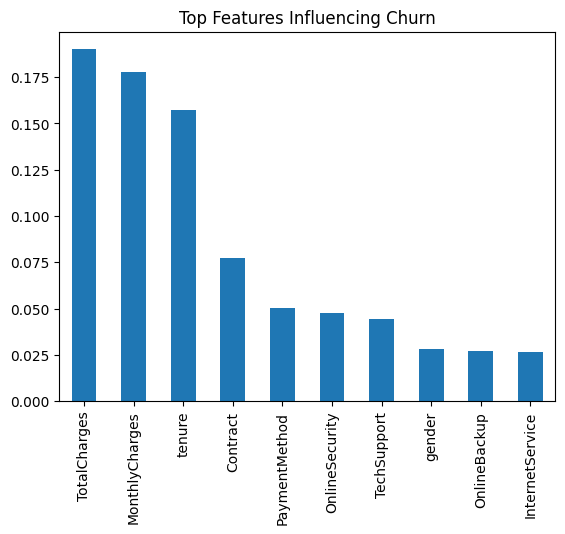

In [18]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Features Influencing Churn")
plt.show()

### 10. Integrating Segmentation with Churn Risk

In [19]:
rfm['Churn'] = y.values
rfm['Churn_Risk'] = rfm['Churn'].apply(lambda x: "High Risk" if x == 1 else "Low Risk")

### 11. Customer Strategy Matrix

In [20]:
pd.crosstab(rfm['Segment'], rfm['Churn_Risk'])

Churn_Risk,High Risk,Low Risk
Segment,,
High Value,329,441
Low Value,153,1575
Mid Value,1387,3158


### 12. Business Recommendations
High Value Customers with High Churn Risk
Provide targeted discounts or retention offers
Introduce loyalty programs or long-term incentives
Use personalized communication strategies
High Value Customers with Low Churn Risk
Focus on upselling and cross-selling opportunities
Maintain satisfaction through premium services
Low Value Customers with High Churn Risk
Use cost-effective retention strategies such as automated campaigns
Avoid high-cost interventions
Low Value Customers with Low Churn Risk
Minimal strategic focus required
Maintain standard service levels

### 13. Conclusion

This project demonstrates how combining customer segmentation with predictive modeling can provide meaningful business insights.

Key outcomes include:

Identification of high-risk customers
Segmentation of customers based on value
Alignment of analytical results with actionable strategies

This approach enables organizations to prioritize retention efforts efficiently and improve overall customer lifetime value.